<p align="center"><img src="https://github.com/uchiharon/ANN-Overfitting-Lab/blob/main/Images/University_of_Texas_at_Austin_seal.svg.png?raw=true" width="200" height="200" /></p>

# Forward Modeling -- Wave propagation

### **Emmanuel Ikpesu**
### **ei3294**
#### **Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering**

# Q1.1 Finite Difference

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [3]:
# Define parameters and initial conditions

dx = 0.01
dt = 0.005
x = np.arange(0, 1 + dx, dx)
t = np.arange(0, 2.0 + dt, dt)
c = 1.0
u_x0 = np.sin(np.pi * x) + 0.5 * np.sin(3 * np.pi * x)
du_dtx0 = np.zeros(len(x))
u_0t = np.zeros(len(t))
u_Lt = np.zeros(len(t))

In [4]:
# Test CFL condition
CFL = c * dt / dx

print(f"CFL number: {CFL}")
if CFL > 1:
    raise ValueError("CFL condition not met! Reduce dt or increase dx.")

CFL number: 0.5


In [5]:
# Finite Difference Solver for 1D Wave Equation
def fd_solver(u_x0, du_dtx0, u_0t, u_Lt, c, dx, dt):
    """Finite Difference Solver for 1D Wave Equation.
    Args:
        u_x0 (np.ndarray): Initial displacement at t=0.
        du_dtx0 (np.ndarray): Initial velocity at t=0.
        u_0t (np.ndarray): Boundary condition at x=0 for all t.
        u_Lt (np.ndarray): Boundary condition at x=L for all t.
        c (float): Wave speed.
        dx (float): Spatial step size.
        dt (float): Time step size.
    Returns:
        np.ndarray: Displacement u(x,t) over space and time.
    """
    n = len(u_x0) - 1
    m = len(u_0t) - 1
    u = np.zeros((m + 1, n + 1))
    u[0, :] = u_x0
    u[:, 0] = u_0t
    u[:, -1] = u_Lt


    for j in range(0, m):
        for i in range(1, n):
            if j == 0:
                u[j + 1, i] = (u[0, i] + du_dtx0[i] * dt 
                               + 0.5 * c**2 * (u[0, i+1] - 2 * u[0, i] + u[0, i-1]) * (dt**2) / (dx**2))
            else:
                u[j + 1, i] = (2 * u[j, i] - u[j - 1, i] 
                               + c**2 * (u[j, i + 1] - 2 * u[j, i] + u[j, i - 1]) * (dt**2) / (dx**2))
    return u

In [6]:
# Solve the wave equation using finite differences
u_sol = fd_solver(u_x0, du_dtx0, u_0t, u_Lt, c, dx, dt)

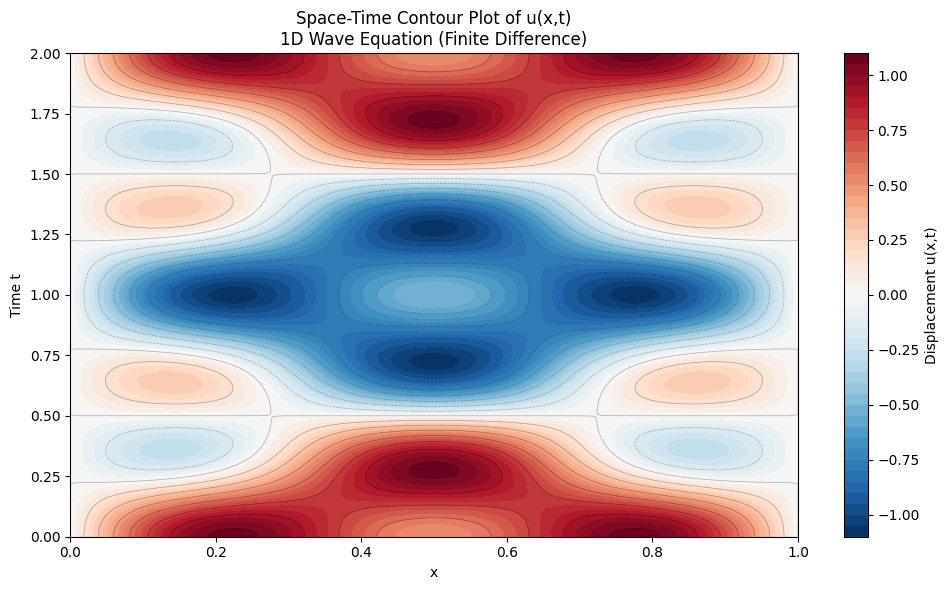

In [7]:
# Space-time contour plot
X, T_grid = np.meshgrid(x, t)
plt.figure(figsize=(10, 6))
contour = plt.contourf(X, T_grid, u_sol, levels=50, cmap='RdBu_r')
plt.colorbar(contour, label='Displacement u(x,t)')
plt.contour(X, T_grid, u_sol, levels=20, colors='black', alpha=0.3, linewidths=0.5)
plt.xlabel('x')
plt.ylabel('Time t')
plt.title('Space-Time Contour Plot of u(x,t)\n1D Wave Equation (Finite Difference)')
plt.tight_layout()
plt.show()

Text(0.5, 0, 'x')

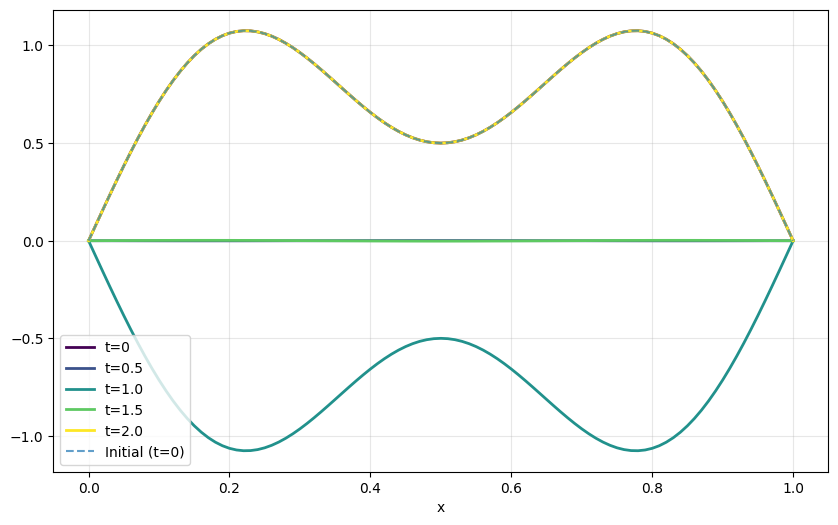

In [8]:
t_eval = [0,0.5,1.0,1.5,2.0]
t_eval_idx = [list(t).index(v) for v in t_eval]
colors = plt.cm.viridis(np.linspace(0, 1, len(t_eval)))

plt.figure(figsize=(10, 6))
for idx, time in zip(t_eval_idx, t_eval):
        plt.plot(x, u_sol[idx, :], label=f't={time}', linewidth=2, color=colors[t_eval_idx.index(idx)])
plt.plot(x, u_sol[0, :], label=f'Initial (t=0)', linestyle='--', linewidth=1.5, alpha=0.7)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlabel('x')

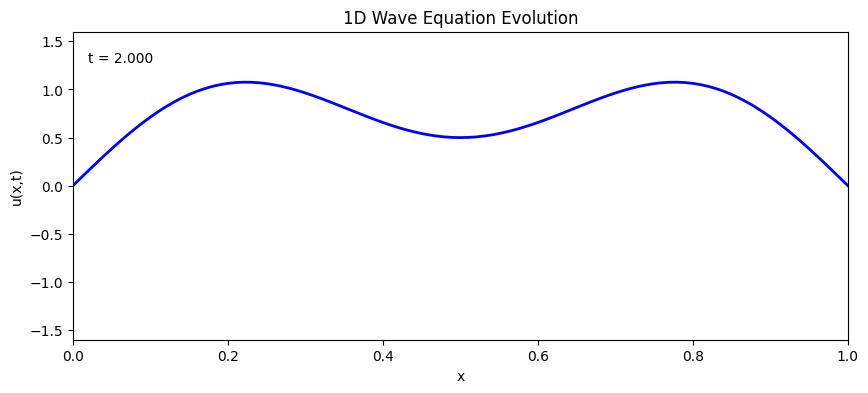

In [9]:
# Optional: Animation
fig, ax = plt.subplots(figsize=(10, 4))
line, = ax.plot(x, u_sol[0, :], 'b-', linewidth=2)
ax.set_xlim(0, 1)
ax.set_ylim(-1.6, 1.6)
ax.set_xlabel('x')
ax.set_ylabel('u(x,t)')
ax.set_title('1D Wave Equation Evolution')
time_text = ax.text(0.02, 0.9, '', transform=ax.transAxes)

def animate(n):
    line.set_ydata(u_sol[n, :])
    time_text.set_text(f't = {t[n]:.3f}')
    return line, time_text

ani = FuncAnimation(fig, animate, frames=len(t), interval=30, blit=False)
ani.save('wave_1d_fd.gif', writer='pillow', fps=30)  # Uncomment to save
plt.show()